# Analysis of the Urus del Lago Poopó, Bolivia (Censo de Población y vivienda 2024)

The Urus del Lago Poopó inhabited the shores and islands of Lake Poopó in the Oruro department of Bolivia. Their communities: **Puñaca Tinta María**, **Vilañeque**, and **Llapallapani** are located across three municipalities: Poopó, Challapata, and Santiago de Huari.

In this notebook, we extract:

- **Population** : Total count of people self-identifying as Urus del lago Poopó, filtered by sex and place of residence
- **Age structure** : For the Uru people living in their core municipalities
- **Economic activity** : Occupation and labor-market by gender
- **Migration** : Local and international migration patterns 

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
from src import ine_micro, plots
path_root = Path.cwd()
cpv_parquet_data = path_root / "censo_2024_data"



The census uses numeric codes to identify indigenous communities. Below we define the codes needed to isolate the Urus del lago Poopó from the rest of the dataset.

There are three distinct Uru peoples in Bolivia: Urus del lago Poopó, Uru-Chipaya, and Urus-uruhito, each with their own census code.

The Urus del lago Poopó have three recognized communities, each in a different municipality within the Oruro department: Puñaca Tinta María, Vilañique, and Llapallapani.

These municipal codes are used throughout the notebook to filter records to individuals living near the lake Poopó territory, separate from community members who have migrated elsewhere in Bolivia.


In [3]:
urus_lago_poopo  = 78  
urus_uruhito = 466
urus_chipaya = 40
dep_oruro = 4  

municipios_poopo = {
    "Puñaca Tinta María":   {"municipio": "Poopó",             "mun_res_cod": 40601},
    "Vilañique":            {"municipio": "Challapata",        "mun_res_cod": 40201},
    "Llapallapani":         {"municipio": "Santiago de Huari", "mun_res_cod": 41401},
}
mun_uru_poopo_codes = [c["mun_res_cod"] for c in municipios_poopo.values()]
mun_uru_poopo_names = [c["municipio"] for c in municipios_poopo.values()]


In [4]:
db = ine_micro.CensoDB(cpv_parquet_data)

# Population

This section counts all Bolivian residents who self-identified as **Urus del lago Poopó** (code 78) in the 2024 census, regardless of their current place of residence. Results are filtered by sex and municipality of residence.



In [5]:
pueblo = db.pueblo_count(pueblo_code=urus_lago_poopo)
display(pueblo.head(5))
total = pueblo.n_personas.sum()
print(f"\n Total de personas que se autoidentifican como Urus del Lago Poopó en Bolivia: {total:,}")
total_m = pueblo.loc[pueblo['sexo'] == 1, 'n_personas'].sum()
total_h = pueblo.loc[pueblo['sexo'] == 2, 'n_personas'].sum()
print(f"  Mujeres: {total_m:,} ({100*total_m/total:.1f}%)")
print(f"  Hombres: {total_h:,} ({100*total_h/total:.1f}%)\n")



total_near_lake_poopo = pueblo.loc[pueblo['mun_residencia'].isin(mun_uru_poopo_names), 'n_personas'].sum()
print(f"\n Total de Urus del Lago Poopó que viven en los municipios de Poopó, Challapata y Santiago de Huari:  {total_near_lake_poopo:,}")


,dep_residencia,mun_residencia,sexo,n_personas
0,Oruro,Santiago de Huari,2,204
1,Oruro,Santiago de Huari,1,184
2,Oruro,Uru Chipaya (Nación Originaria Uru Chipaya),1,86
3,Oruro,Uru Chipaya (Nación Originaria Uru Chipaya),2,85
4,Oruro,Oruro,2,49



 Total de personas que se autoidentifican como Urus del Lago Poopó en Bolivia: 1,170
  Mujeres: 528 (45.1%)
  Hombres: 642 (54.9%)


 Total de Urus del Lago Poopó que viven en los municipios de Poopó, Challapata y Santiago de Huari:  544



The gap between these two numbers reflects the extent of internal migration away from ancestral lands.

# Age structure



In [6]:
age_dist = db.age_structure(pueblo_code=urus_lago_poopo)

print(f"Age distribution of Uru people living in the municipios: Challapata, Poopó and Santiago de Huari:")
display(age_dist)

Age distribution of Uru people living in the municipios: Challapata, Poopó and Santiago de Huari:


,grupo_edad,Hombre,Mujer
0,0-19,225,212
1,20-39,193,180
2,40-59,139,95
3,60+,85,41


# Economic activity

This section profiles the occupational status  and reasons for inactivity of Uru men and women living in their three core municipalities. 


 Actividad económica de los y las Urus del Lago Poopó:


,n_mujeres,n_hombres
actividad_economica,,
"A: Agricultura, ganadería, silvicultura y pesca",15.0,31.0
B: Explotación de minas y canteras,0.0,11.0
C: Industrias manufactureras,14.0,14.0
Descripciones incompletas,0.0,1.0



 Motivos por los que no tienen un trabajo actual:


,razon_inactividad,n_mujeres,n_hombres
0,Buscó trabajo por primera vez,1.0,4
1,"Esta jubilada(o), es pensionista o rentista",2.0,2
2,Estuvo como pasante o aprendiz sin recibir pago,0.0,1
3,Estuvo estudiando,62.0,66


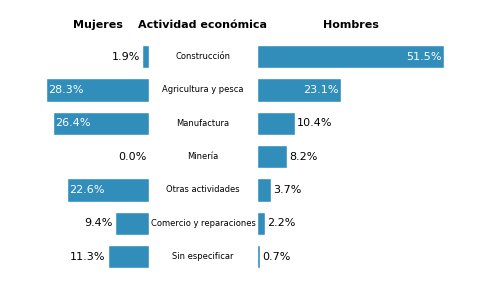

In [7]:

perfil_mujeres = db.pueblo_occupation(pueblo_code=urus_lago_poopo, gender=1, municipios= mun_uru_poopo_codes)
perfil_hombres = db.pueblo_occupation(pueblo_code=urus_lago_poopo, gender=2, municipios= mun_uru_poopo_codes)

print("\n Actividad económica de los y las Urus del Lago Poopó:")
ocu_m = perfil_mujeres["ocupacion"]
ocu_h = perfil_hombres["ocupacion"]

ocu_m  = ocu_m[["actividad_economica", "n"]]
ocu_h  = ocu_h[["actividad_economica", "n"]]
ocu_m = ocu_m.groupby("actividad_economica")[["n"]].sum().sort_values(by="n", ascending=False)
ocu_h = ocu_h.groupby("actividad_economica")[["n"]].sum().sort_values(by="n", ascending=False)

urus_working= pd.merge(ocu_m, ocu_h, on="actividad_economica", how="outer", suffixes=("_mujeres","_hombres"))
urus_working = urus_working.fillna(0)
display(urus_working.head(4))

print("\n Motivos por los que no tienen un trabajo actual:")
no_ocu_m = perfil_mujeres["no_ocupados"]
no_ocu_h = perfil_hombres["no_ocupados"]
urus_no_working= pd.merge(no_ocu_m, no_ocu_h, on="razon_inactividad", how="outer", suffixes=("_mujeres","_hombres"))
urus_no_working = urus_no_working.fillna(0)
display(urus_no_working.head(4))

plots.figura_actividad_economica(urus_working.reset_index())


The economic activity data reveals that the lake's disappeareance has fundamentally altered the livelihoods of a community historically known as fishers and gatherers.

# International migration

In this section, we examine the international emigration patterns among Uru people households. The 2024 census collected data on household members who have emigrated abroad, including their sex and year of departure.



Familiares mujeres que migraron fuera del país: 



,salida_año,pais_destino,edad_salida,n_migrantes
0,1983,Estados Unidos de América,25,1
1,1987,Estados Unidos de América,28,1
2,1990,Estados Unidos de América,25,1
3,1991,Estados Unidos de América,21,1
4,1999,Argentina,999,1


Familiares hombres que migraron fuera del país:



,salida_año,pais_destino,edad_salida,n_migrantes
0,1999,Argentina,999,1
1,2000,Argentina,28,1
2,2001,Argentina,30,1
3,2002,Argentina,999,2
4,2003,España,19,1


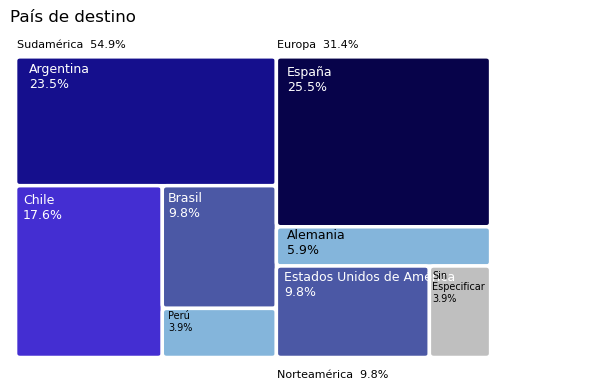

In [8]:
print("Familiares mujeres que migraron fuera del país: \n")
migra_m = db.international_migration(gender=1, pueblo_code=urus_lago_poopo)
display(migra_m.head(5))

print("Familiares hombres que migraron fuera del país:\n")
migra_h = db.international_migration(gender=2, pueblo_code=urus_lago_poopo)
display(migra_h.head(5))

total_migra = pd.concat([migra_h, migra_m])
total_migra = total_migra.sort_values(by="salida_año", ascending=True)

plots.figura_migracion(total_migra)